In [12]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "productivity"
dsetnamex = "Productivity"
d = 11

######
graphsx = np.load("../graphs/"+dsetname+"_thresh_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/productivity_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Productivity (11),4.0,112,50,39,11,20.330357,15.991071,4.339286,45.54,9.069088,7.081356,1.987732,0,1,7,0,0
1,Productivity (11),4.5,112,50,39,11,25.598214,19.982143,5.616071,57.34,14.040155,10.830350,3.209805,0,0,6,0,1
2,Productivity (11),5.0,112,50,39,11,32.116071,25.080357,7.035714,71.94,21.887921,17.002419,4.885502,0,0,6,0,2
3,Productivity (11),5.5,112,50,39,11,38.803571,30.339286,8.464286,86.92,31.333333,24.426060,6.907273,0,0,6,0,3
4,Productivity (11),6.0,112,50,39,11,44.241071,34.562500,9.678571,99.10,39.637286,30.956494,8.680793,0,0,5,1,4
5,Productivity (11),6.5,112,50,39,11,46.696429,36.419643,10.276786,104.60,43.723010,34.105221,9.617789,0,0,5,13,5
6,Productivity (11),7.0,112,50,39,11,47.491071,37.035714,10.455357,106.38,45.163874,35.214631,9.949243,0,0,5,25,6
7,Productivity (11),7.5,112,50,39,11,47.732143,37.223214,10.508929,106.92,45.621334,35.569610,10.051724,0,0,5,35,7
8,Productivity (11),8.0,112,50,39,11,47.767857,37.258929,10.508929,107.00,45.689655,35.637931,10.051724,0,0,5,39,8
9,Productivity (11),8.5,112,50,39,11,47.839286,37.303571,10.535714,107.16,45.798068,35.701127,10.096940,0,0,4,5,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=True)


summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,r,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,productivity (11),0,4.0,112,50,67.503858,29.294709,78.0,34.0,...,0.2,4.92,2.08,93.39267,92.35685,86.54341,86.16090,93.39267,92.35685,0.075826
1,2,productivity (11),0,4.0,112,50,71.392791,31.205835,78.0,34.0,...,0.2,4.92,2.08,98.76908,98.38437,91.52936,91.78180,98.76908,98.38437,0.150375
2,3,productivity (11),0,4.0,112,50,72.181464,31.521214,78.0,34.0,...,0.2,4.92,2.08,99.86350,99.37653,92.54052,92.70939,99.86350,99.37653,0.225348
3,4,productivity (11),0,4.0,112,50,72.276872,31.541782,78.0,34.0,...,0.2,4.92,2.08,99.99571,99.44138,92.66295,92.76988,99.99571,99.44138,0.288760
4,5,productivity (11),0,4.0,112,50,72.280000,31.541782,78.0,34.0,...,0.2,4.92,2.08,100.00000,99.44138,92.66696,92.76988,100.00000,99.44138,0.307423
5,1,productivity (11),1,4.5,112,50,71.614846,31.443350,78.0,34.0,...,0.0,4.27,1.73,97.13232,97.44476,91.81395,92.48044,97.13232,97.44476,0.089331
6,2,productivity (11),1,4.5,112,50,72.913185,31.739787,78.0,34.0,...,0.0,4.27,1.73,98.89304,98.36063,93.47840,93.35229,98.89304,98.36063,0.175836
7,3,productivity (11),1,4.5,112,50,73.490633,31.870450,78.0,34.0,...,0.0,4.27,1.73,99.67599,98.76319,94.21866,93.73657,99.67599,98.76319,0.261438
8,4,productivity (11),1,4.5,112,50,73.681178,31.913358,78.0,34.0,...,0.0,4.27,1.73,99.93409,98.89821,94.46318,93.86276,99.93409,98.89821,0.341930
9,5,productivity (11),1,4.5,112,50,73.730000,31.924110,78.0,34.0,...,0.0,4.27,1.73,100.00000,98.93187,94.52586,93.89438,100.00000,98.93187,0.386999


## Plots

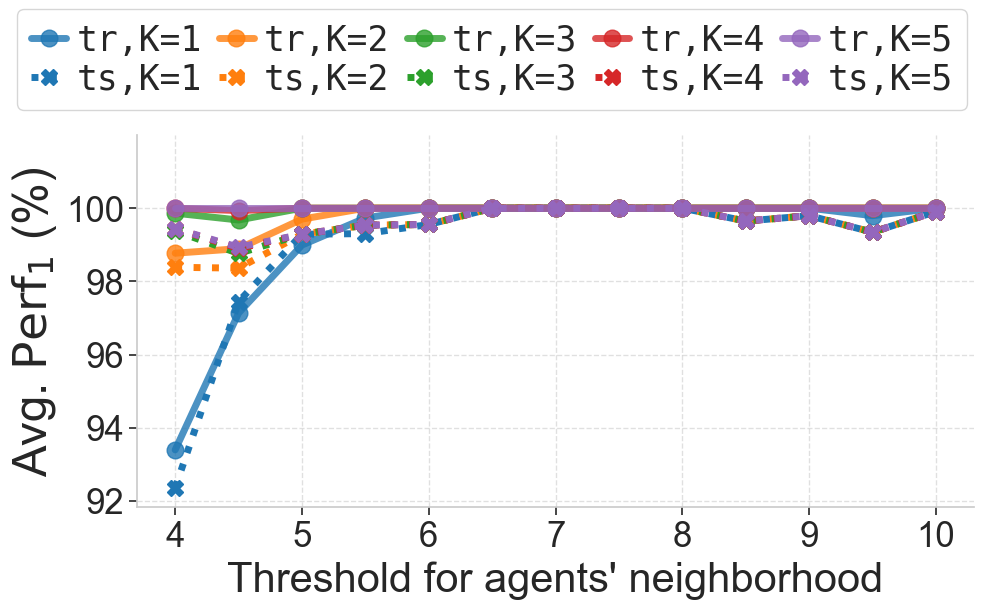

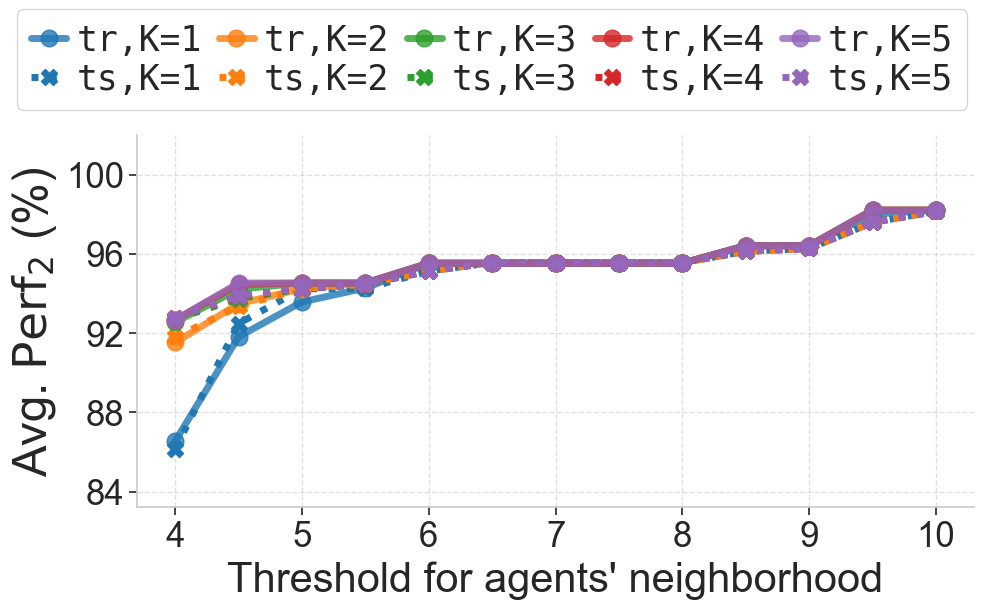

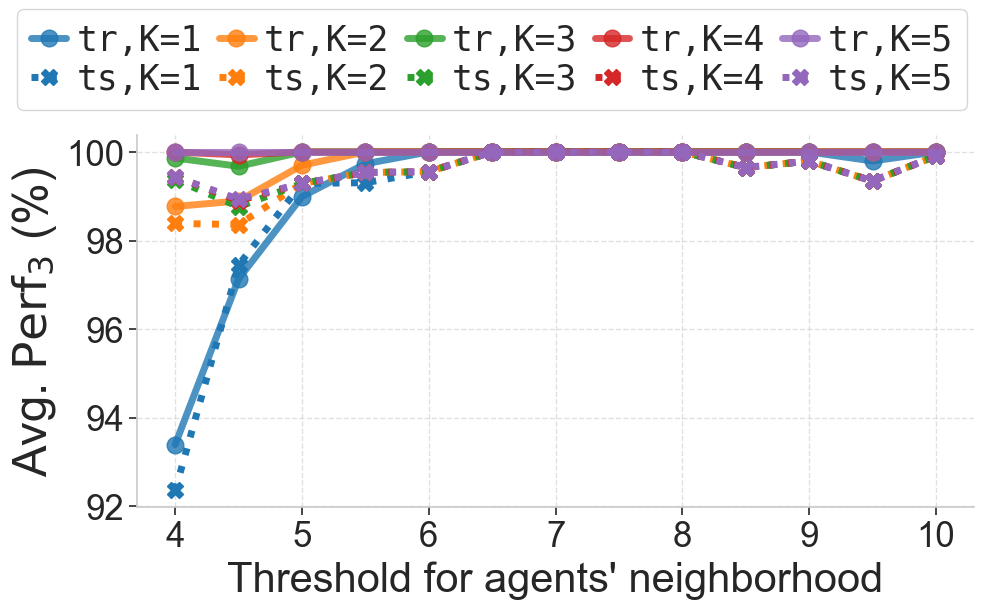

In [13]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf3.pdf")

